# Импорт библиотек

In [46]:
import numpy as np
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("/kaggle/input/gym-members-exercise-dataset/gym_members_exercise_tracking.csv")

# Доп функции

In [11]:
def get_outliers(col: str) -> pd.DataFrame:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outlier_idx = df[(df[col] < lower) | (df[col] > upper)].index
    
    return df.loc[outlier_idx]

# Анализ данных

In [2]:
df.head(10)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
5,56,Female,58.0,1.68,168,156,74,1.59,1116.0,HIIT,15.5,2.7,5,3,20.55
6,36,Male,70.3,1.72,174,169,73,1.49,1385.0,Cardio,21.3,2.3,3,2,23.76
7,40,Female,69.7,1.51,189,141,64,1.27,895.0,Cardio,30.6,1.9,3,2,30.57
8,28,Male,121.7,1.94,185,127,52,1.03,719.0,Strength,28.9,2.6,4,2,32.34
9,28,Male,101.8,1.84,169,136,64,1.08,808.0,Cardio,29.7,2.7,3,1,30.07


Посмотрим на информацию о датасете

In [3]:
df.info()

df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

In [4]:
print(f"Всего записей: {len(df)}")

print(f"Всего пропущенных значений: {df.isna().iloc[:,0].sum()}")

print()

print(f"Число численных      признаков: {df.dtypes[df.dtypes != 'object'].value_counts().sum()}")
print(f"Число категориальных признаков: {df.dtypes[df.dtypes == 'object'].value_counts().sum()}")

df.dtypes

Всего записей: 973
Всего пропущенных значений: 0

Число численных      признаков: 13
Число категориальных признаков: 2


Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                      object
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object

In [5]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


Посмотрим на распределение пола людей

(array(['Female', 'Male'], dtype=object), array([462, 511]))


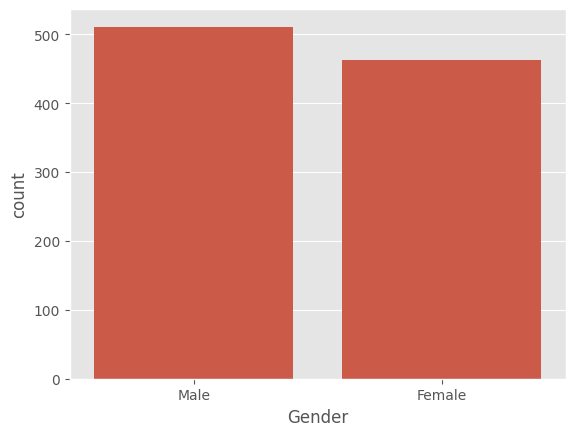

In [33]:
sns.countplot(df, x="Gender")

print(np.unique(df["Gender"], return_counts=True))

plt.show()

Датасет является довольно сбалансированным относительно пола людей

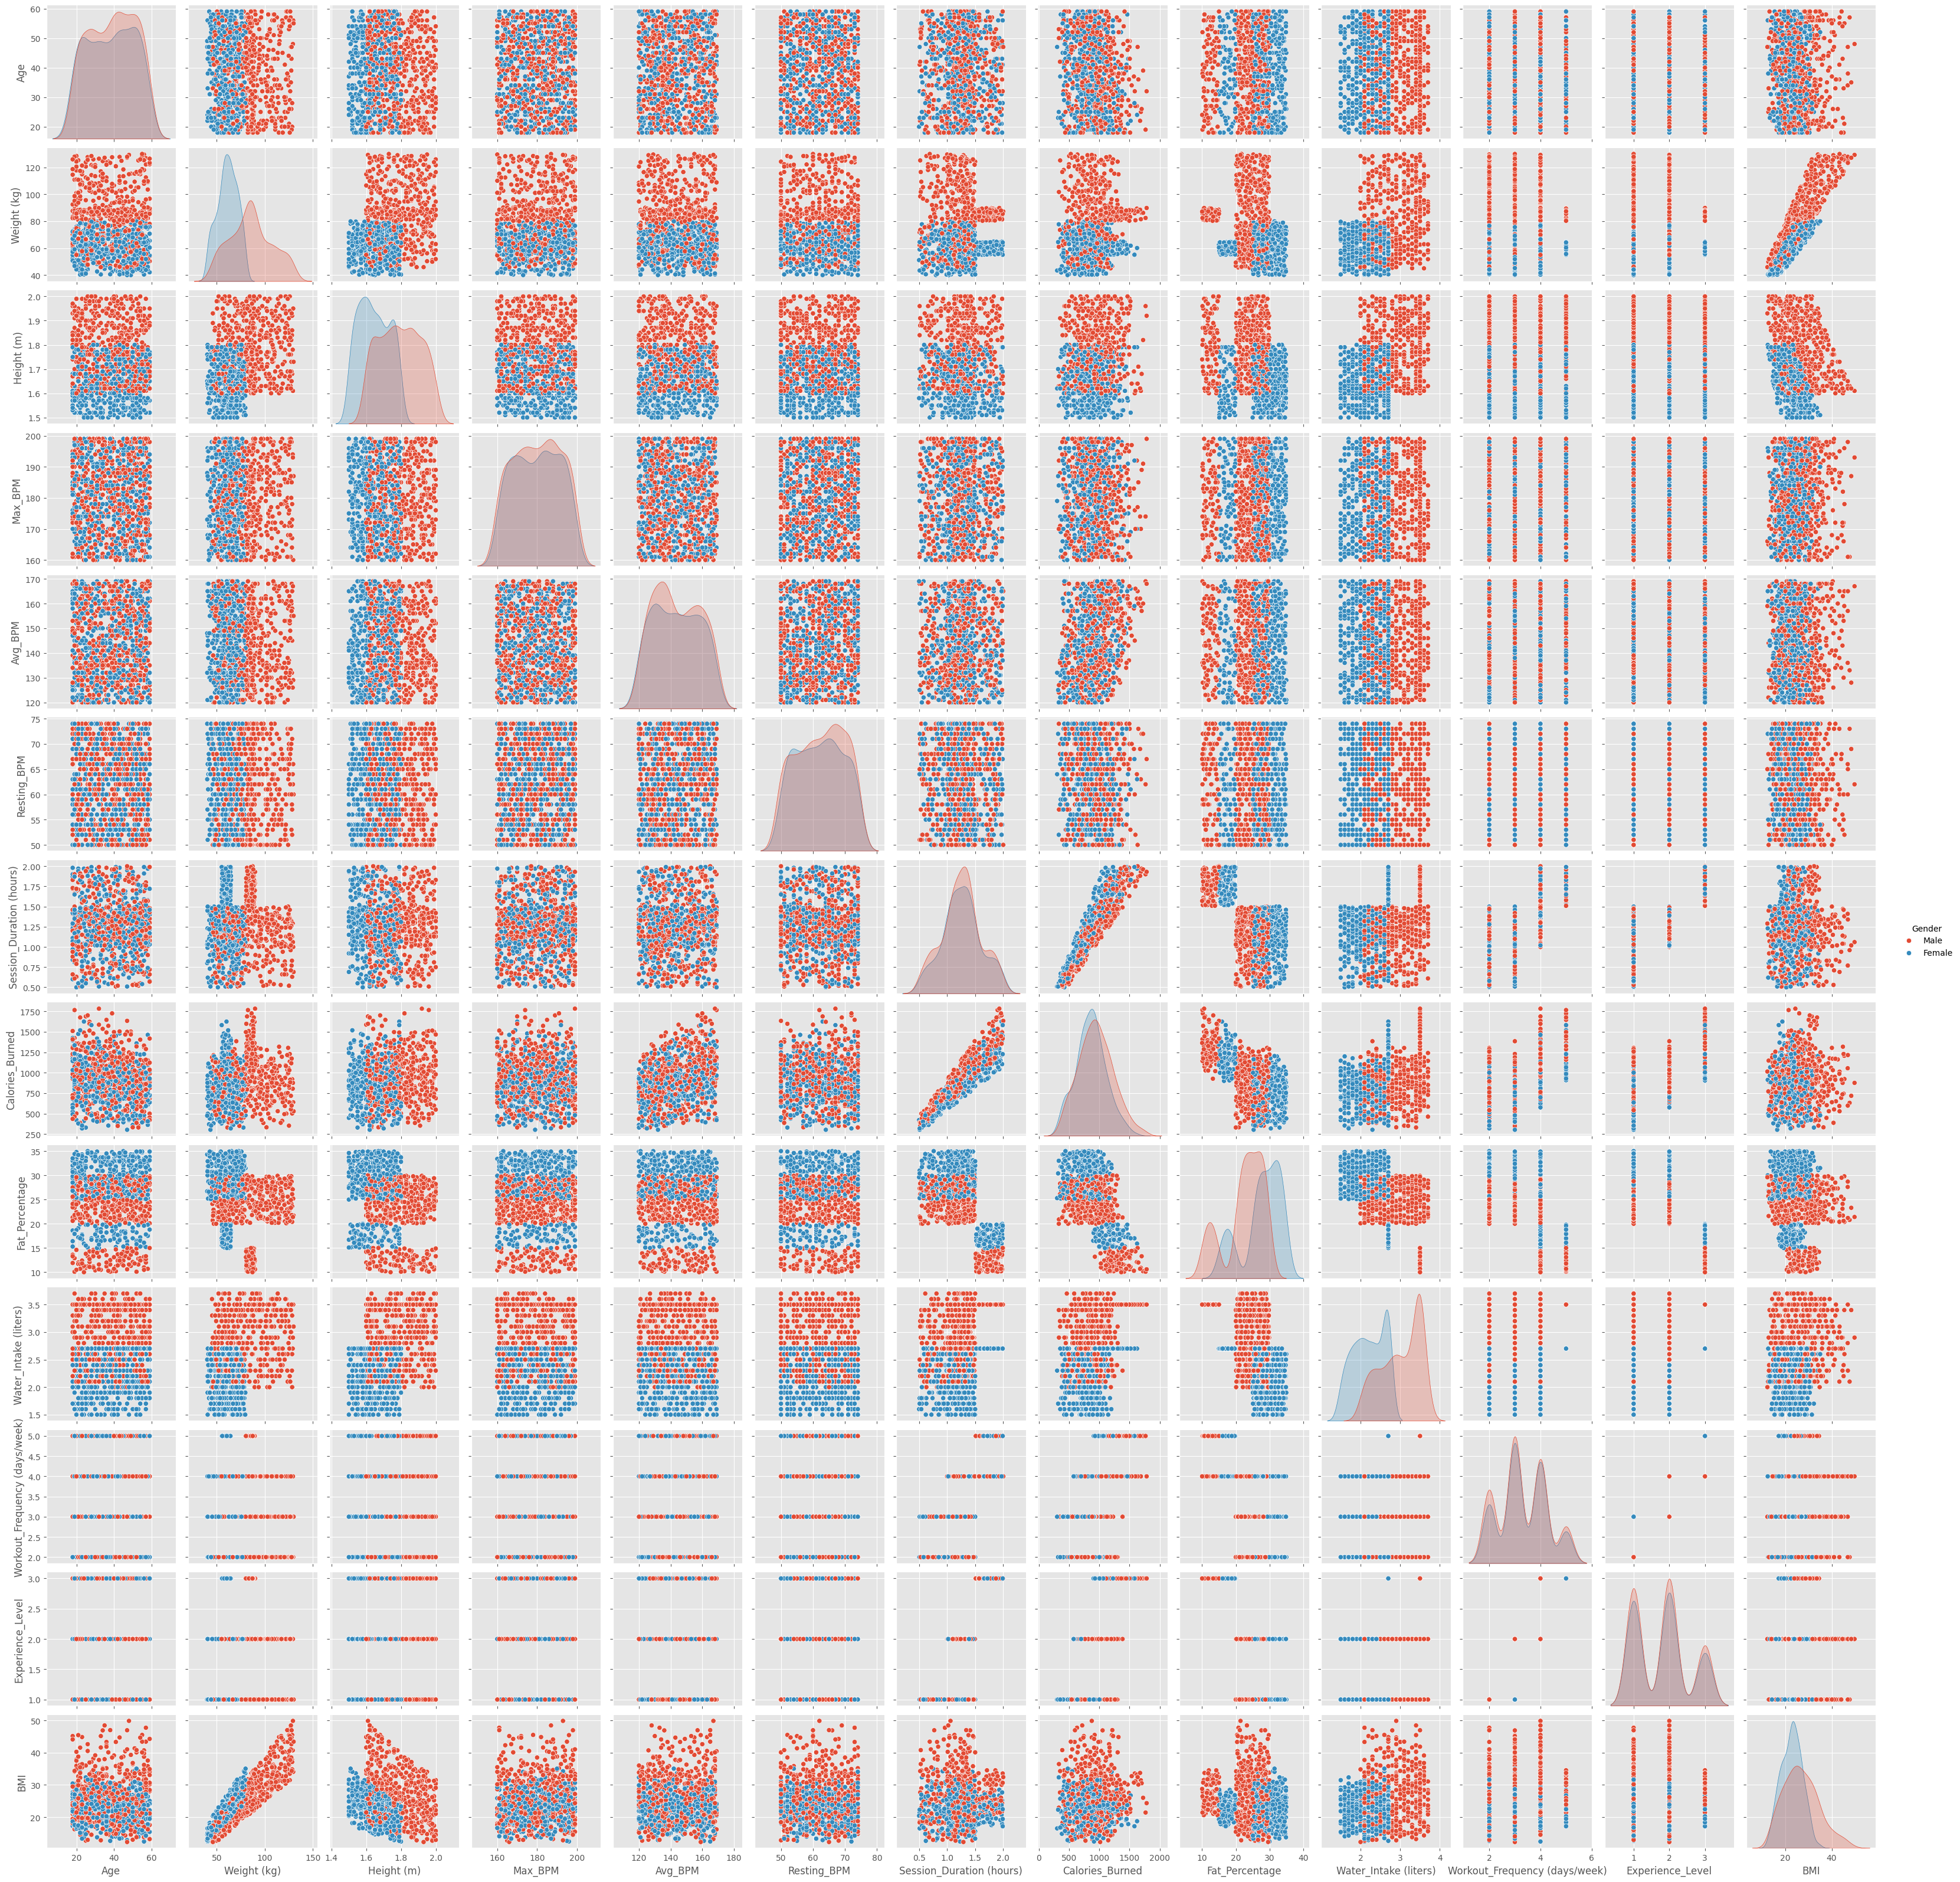

In [23]:
sns.pairplot(df, hue="Gender")
plt.show()

Построим boxplot'ы для проверки данных на выбросы

Число выбросов для каждого признака:
Age: 0
Weight (kg): 9
Height (m): 0
Max_BPM: 0
Avg_BPM: 0
Resting_BPM: 0
Session_Duration (hours): 0
Calories_Burned: 10
Fat_Percentage: 0
Water_Intake (liters): 0
Workout_Frequency (days/week): 0
Experience_Level: 0
BMI: 25


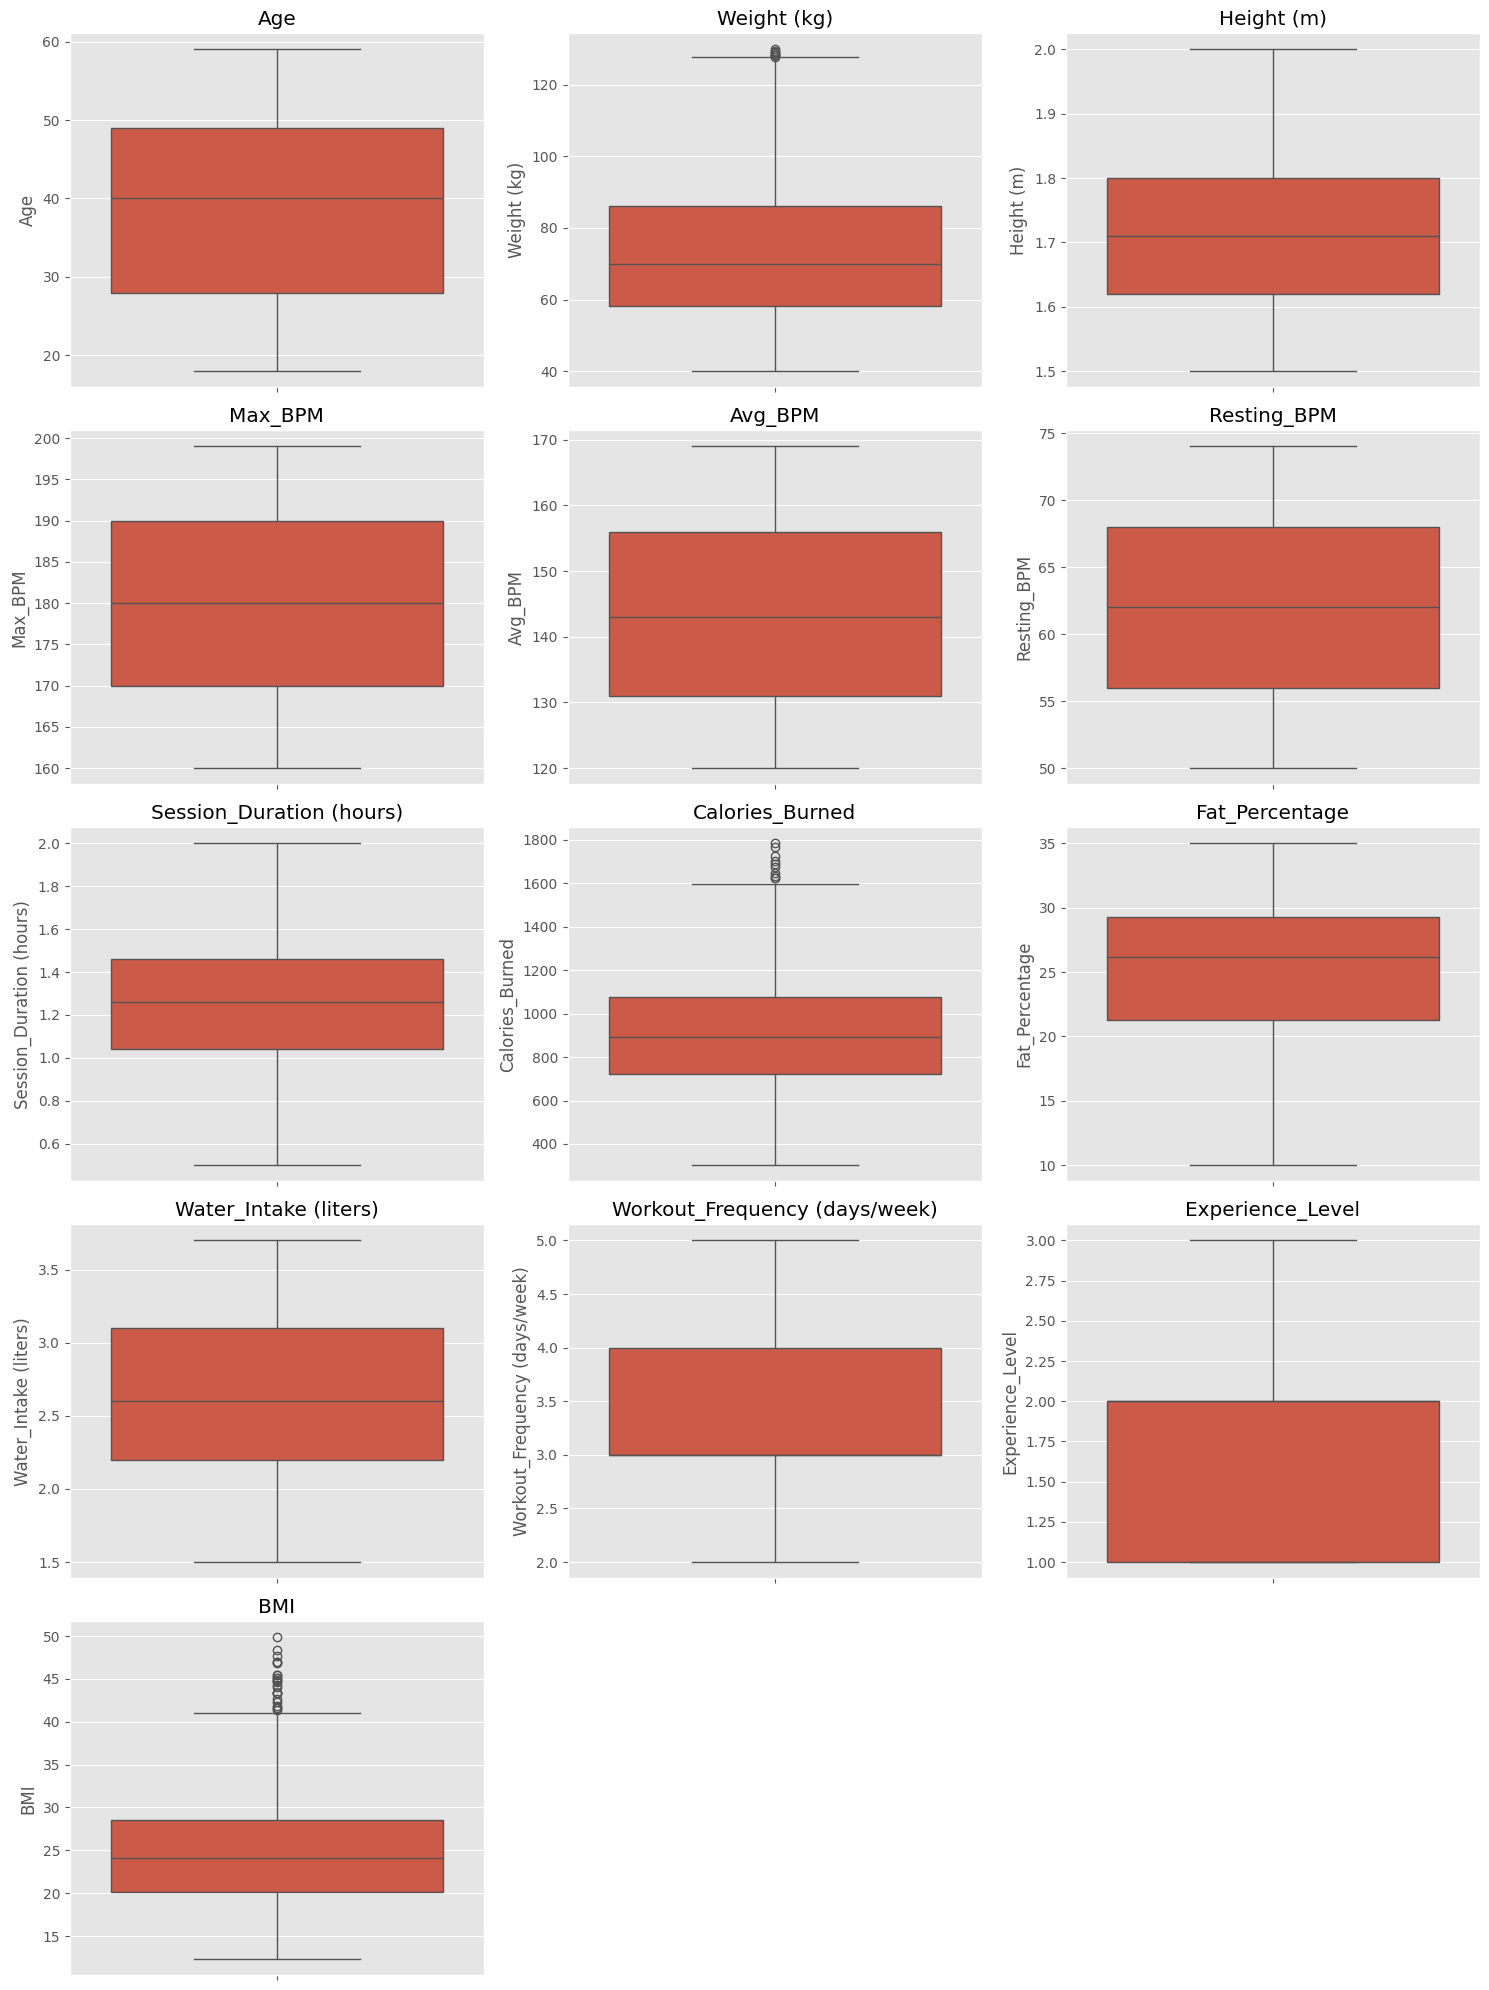

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def get_num_outliers(column):
    q1 = np.percentile(column, 25)
    q3 = np.percentile(column, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((column < lower) | (column > upper)).sum()

numeric_cols = df.select_dtypes(include=[np.number]).columns
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

print("Число выбросов для каждого признака:")
for col in numeric_cols:
    print(f"{col}: {get_num_outliers(df[col])}")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Индекс массы тела (BMI)

| Индекс массы тела | Соответствие между массой человека и его ростом |
|-------------------|-----------------------------------------------|
| 16 и менее        | Выраженный дефицит массы тела                 |
| 16—18,5           | Недостаточная (дефицит) масса тела            |
| 18,5—25           | Норма                                         |
| 25—30             | Избыточная масса тела (предожирение)          |
| 30—35             | Ожирение 1 степени                            |
| 35—40             | Ожирение 2 степени                            |
| 40 и более        | Ожирение 3 степени                            |

Видим, что наши выбросы по BMI принимают значения около 50, что соответствует ожирению 3 степени

## Калории

Кол-во соженных калорий для выбросов отвечает за ОЧЕНЬ интенсивную тренировку или даже марафон. Поэтому стоит сильнее обратить внимание на объекты с завышенным показателем. Давайте сделаем это

In [12]:
get_outliers("Calories_Burned")

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
90,25,Male,81.5,1.61,170,159,63,1.93,1688.0,HIIT,10.9,3.5,4,3,31.44
99,24,Female,60.1,1.79,170,165,63,1.97,1625.0,Cardio,15.9,2.7,4,3,18.76
124,26,Male,86.2,1.68,189,157,72,1.97,1701.0,Strength,13.3,3.5,5,3,30.54
475,27,Male,89.3,1.64,192,162,64,1.82,1622.0,HIIT,12.1,3.5,4,3,33.20
511,39,Male,86.2,1.82,191,160,72,1.96,1725.0,Strength,10.2,3.5,5,3,26.02
572,36,Male,88.0,1.71,185,160,73,1.87,1646.0,HIIT,12.0,3.5,5,3,30.09
646,22,Male,88.5,1.62,174,162,69,1.88,1675.0,Strength,10.7,3.5,5,3,33.72
712,19,Male,82.4,1.96,174,169,62,1.90,1766.0,HIIT,10.1,3.5,5,3,21.45
728,47,Male,87.2,1.64,177,165,50,2.00,1634.0,Strength,15.0,3.5,4,3,32.42
910,32,Male,89.8,1.92,199,168,67,1.93,1783.0,Strength,10.6,3.5,4,3,24.36


Давайте посмотрим на первого кандидата

Видим его `Workout_Type` = `HIIT` — это **High-intensity interval training**

Читаем информацию про эту тренировку на википедии:
```
The entire HIIT session may last between four and 30 minutes, meaning that it is considered to be an excellent way to maximize a workout limited by time constraints
An alternative form of HIIT, designed for heart rate training, involves a 30-minute period of cardio followed by 30 minutes of full-body resistance training to help maximize calorie burning
```

Даже АЛЬТЕРНАТИВА `HIIT` длится не больше часа. Наш кандидат занимался почти 2 часа. Получается, либо неправильно обозначен `Workout_Type`, либо кандидат на самом деле занимался `0.93` часа.

Анализируем дальше: `experience_level` — незивестный нам параметр, но принимающий самое высокое значение, говорит нам о том, что кандидат очень опытный — будем учитывать это, рассматривая аномалии в дальнейшем.

Вычитаем в википедии это:
```
Плотность мышечной ткани выше, чем жировой. Фактически все люди с атлетическим и мускулистым телосложением обладают показателями ИМТ выше нормы и при пониженной жировой массе
```
Действительно, вряд ли мы смотрим на кандидата с ожирением, учитывая его опыт и частоту тренировок (`4` раза/неделю)

Замечаем признак `Fat_Percentage`. Он находится в пределах нормы для атлетов (судя по википедии)

Кол-во употребляемой воды и показания пульса находится в пределах нормы для интенсивной тренировки

Например, на данном вебсайте [HIIT Calculator](https://fitliferegime.com/hiit-calories-burned-calculator/) при выставлении максимальных параметров и указания тренировки в `1.93` часа, мы получаем `1620` соженных калорий. В общем, такое возможно, но вряд ли наш кандидат занимался `HIIT`

Выбросов относительно `Calories_Burned` довольно мало, поэтому избавиться от них при построении регрессора будет неплохой идеей.

Теперь обратим внимание на выбросы BMI

In [14]:
get_outliers("BMI")

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
10,41,Male,120.8,1.67,188,146,54,0.82,593.0,HIIT,20.5,3.0,2,1,43.31
12,57,Male,112.5,1.61,195,165,61,1.24,1013.0,Cardio,22.1,2.7,3,2,43.40
35,26,Male,127.6,1.73,167,160,62,1.32,1162.0,Strength,27.3,2.9,3,1,42.63
55,23,Male,114.8,1.60,182,163,60,1.47,1318.0,Cardio,21.7,2.7,4,2,44.84
133,21,Male,125.2,1.66,196,159,60,1.38,1207.0,HIIT,29.8,3.4,3,2,45.43
251,33,Male,117.0,1.61,166,130,55,1.04,744.0,HIIT,25.1,2.4,3,2,45.14
261,57,Male,126.8,1.63,161,133,73,0.96,632.0,Yoga,20.8,2.1,2,1,47.72
291,55,Male,128.4,1.68,178,165,52,1.13,923.0,Cardio,20.4,2.6,4,2,45.49
302,36,Male,123.7,1.69,185,138,73,1.30,987.0,Cardio,20.4,2.1,4,2,43.31
345,43,Male,127.7,1.69,171,155,53,1.14,875.0,Cardio,24.1,2.9,3,2,44.71


Тут, конечно, наблюдаются огромные проблемы с данными. Например, `1229` соженных калорий после занятий ЙОГОЙ (запись `687`)? Огромный `BMI` при низком содержании жира. Эти выбросы явно следует убрать

# Корреляционный анализ

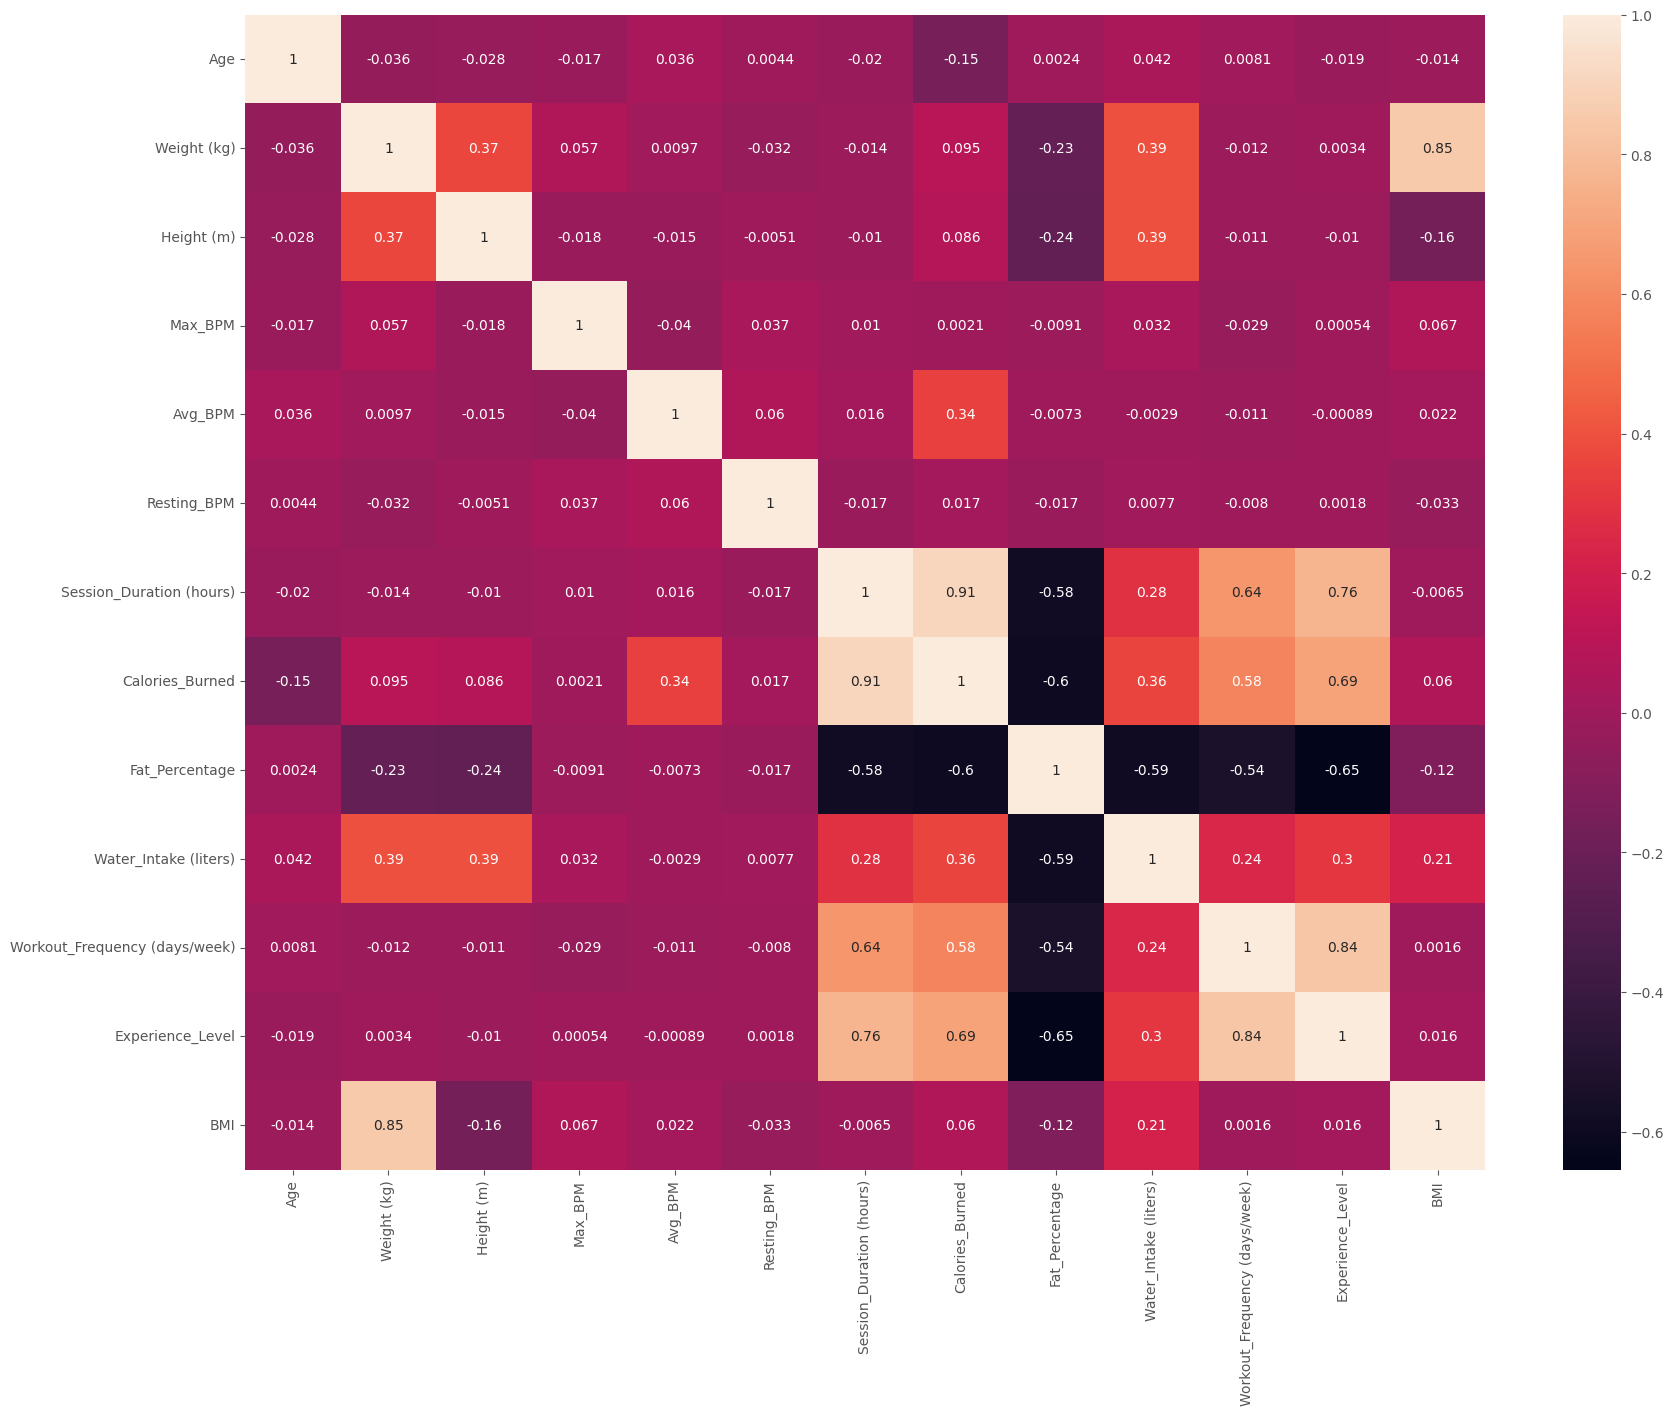

In [17]:
df_corr = df.corr(numeric_only=True)
plt.figure(figsize=(20, 15))
sns.heatmap(df_corr, annot=True)
plt.show()

Видим высокую корреляцию между `BMI` и ростом, что неудивительно, ведь `BMI` ему пропорционален. По факту корреляция должна быть равна `1`

Также видим, что кол-во соженных калорий сильно скоррелированно с временем тренировки, а время тренировки с опытом и частотой тренировок

Женщины оказываются в большинстве ниже мужчин

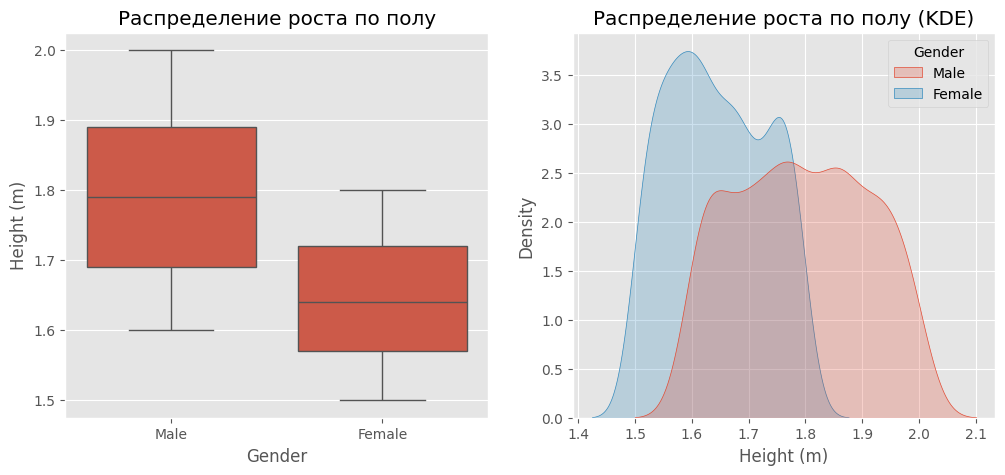

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x="Gender", y="Height (m)", ax=axes[0])
axes[0].set_title("Распределение роста по полу")

sns.kdeplot(data=df, x="Height (m)", hue="Gender", common_norm=False, fill=True, ax=axes[1])
axes[1].set_title("Распределение роста по полу (KDE)")

plt.show()

У женщин в норме бОльшая доля жира, чем у мужчин. Это подтверждается данными

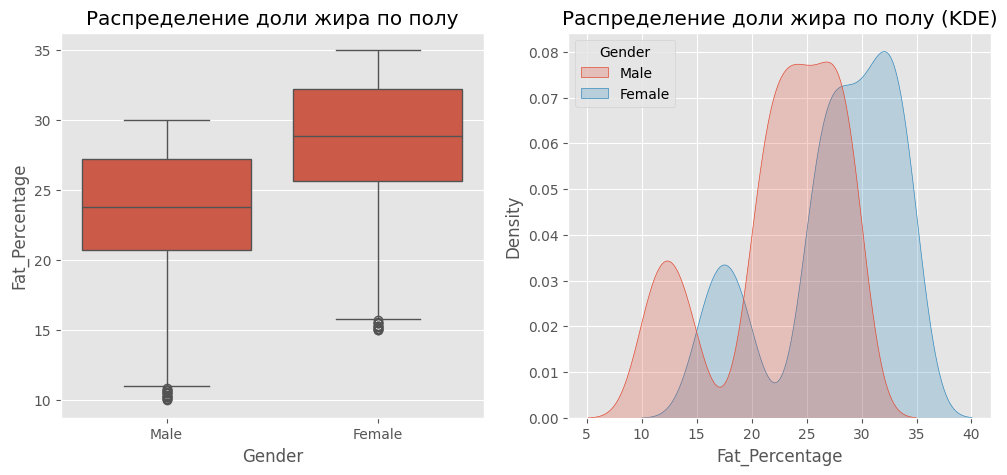

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x="Gender", y="Fat_Percentage", ax=axes[0])
axes[0].set_title("Распределение доли жира по полу")

sns.kdeplot(data=df, x="Fat_Percentage", hue="Gender", common_norm=False, fill=True, ax=axes[1])
axes[1].set_title("Распределение доли жира по полу (KDE)")

plt.show()

Посмотрим на предпочтения в спорте

Кардио является самым популярным среди женщин, а среди мужчин — силовые. На йогу ходит больше мужчин.

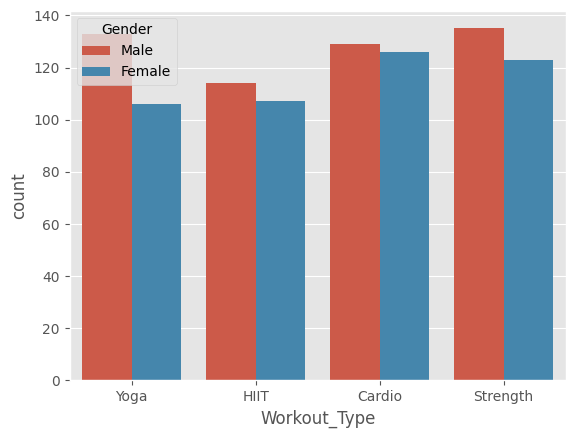

In [38]:
sns.countplot(df, x="Workout_Type", hue="Gender")
plt.show()

В среднем мужчины сжигают больше калорий за тренировку

In [39]:
df.groupby("Gender")["Calories_Burned"].agg(["mean", "sum", "count", "std"])

,mean,sum,count,std
Gender,,,,
Female,862.248918,398359.0,462,249.614915
Male,944.455969,482617.0,511,286.590987


А `HIIT` в среднем занимает первое место по сжиганию калорий, что логично, ведь тренировка на это и нацелена

In [40]:
df.groupby("Workout_Type")["Calories_Burned"].agg(["mean", "sum", "count", "std"])

,mean,sum,count,std
Workout_Type,,,,
Cardio,884.513725,225551.0,255,270.196033
HIIT,925.805430,204603.0,221,274.494781
Strength,910.697674,234960.0,258,270.264091
Yoga,903.188285,215862.0,239,276.141637


# Статистический анализ

# Проверка на нормальность

In [76]:
def check_normality(series, alpha=0.05):
    print(f"\nПроверка нормальности для '{series.name}'")
    
    shapiro_stat, shapiro_p = stats.shapiro(series)
    shapiro_result = "Нормальное" if shapiro_p > alpha else "Не нормальное"
    print(f"  Тест Шапиро-Уилка: p = {shapiro_p:.4f} -> {shapiro_result}")
    
    dagostino_stat, dagostino_p = stats.normaltest(series)
    dagostino_result = "Нормальное" if dagostino_p > alpha else "Не нормальное"
    print(f"  Тест Д'Агостино-Пирсона: p = {dagostino_p:.4f} -> {dagostino_result}")
    
    return shapiro_p, dagostino_p

numeric_cols_to_check = [
    "Resting_BPM", 
    "Calories_Burned", 
    "Session_Duration (hours)", 
    "Workout_Frequency (days/week)",
    "BMI",
    "Fat_Percentage",
    "Height (m)"
]

results = {}
for col in numeric_cols_to_check:
    shapiro_p, dagostino_p = check_normality(df[col])
    results[col] = {
        "Shapiro_p": shapiro_p,
        "D'Agostino_p": dagostino_p,
        "Normal_Shapiro": shapiro_p > 0.05,
        "Normal_Dagostino": dagostino_p > 0.05
    }


Проверка нормальности для 'Resting_BPM'
  Тест Шапиро-Уилка: p = 0.0000 -> Не нормальное
  Тест Д'Агостино-Пирсона: p = 0.0000 -> Не нормальное

Проверка нормальности для 'Calories_Burned'
  Тест Шапиро-Уилка: p = 0.0000 -> Не нормальное
  Тест Д'Агостино-Пирсона: p = 0.0021 -> Не нормальное

Проверка нормальности для 'Session_Duration (hours)'
  Тест Шапиро-Уилка: p = 0.0000 -> Не нормальное
  Тест Д'Агостино-Пирсона: p = 0.0270 -> Не нормальное

Проверка нормальности для 'Workout_Frequency (days/week)'
  Тест Шапиро-Уилка: p = 0.0000 -> Не нормальное
  Тест Д'Агостино-Пирсона: p = 0.0000 -> Не нормальное

Проверка нормальности для 'BMI'
  Тест Шапиро-Уилка: p = 0.0000 -> Не нормальное
  Тест Д'Агостино-Пирсона: p = 0.0000 -> Не нормальное

Проверка нормальности для 'Fat_Percentage'
  Тест Шапиро-Уилка: p = 0.0000 -> Не нормальное
  Тест Д'Агостино-Пирсона: p = 0.0000 -> Не нормальное

Проверка нормальности для 'Height (m)'
  Тест Шапиро-Уилка: p = 0.0000 -> Не нормальное
  Тест Д'Аг

## Гипотеза №1

H0: ```Средний пульс в покое у мужчин и женщин одинаков```

H1: ```Средний пульс в покое у мужчин и женщин различается```

In [66]:
alpha = 0.05

male_rpm = df[df["Gender"] == "Male"]["Resting_BPM"]
female_rpm = df[df["Gender"] == "Female"]["Resting_BPM"]

t1, p1 = stats.ttest_ind(male_rpm, female_rpm, equal_var=False)
print(f"Гипотеза 1:")
print(f"  t = {t1:.3f}, p = {p1:.3f}")
print(f"  {"Отклоняем H0" if p1 < alpha else "Не отклоняем H0"} (уровень значимости >= {alpha})\n")

Гипотеза 1:
  t = 0.439, p = 0.661
  Не отклоняем H0 (уровень значимости >= 0.05)



# Гипотеза №2

H0: ```Среднее количество сожжённых калорий одинаково у новичков и опытных```

H1: ```Опытные сжигают значительно больше калорий```

In [54]:
beginners = df[df["Experience_Level"] == 1]["Calories_Burned"]
experts = df[df["Experience_Level"] == 3]["Calories_Burned"]

t2, p2 = stats.ttest_ind(experts, beginners, equal_var=False)
print(f"Гипотеза 2:")
print(f"  t = {t2:.3f}, p = {p2:.3f}")
print(f"  {'Отклоняем H0' if p2 < alpha else 'Не отклоняем H0'}\n")

Гипотеза 2:
  t = 30.119, p = 0.000
  Отклоняем H0

